# OpenMC-Based Physics-Informed Deep Reinforcement Learning for BWR Fuel Assembly Enrichment Layout

*A neural-network policy trained with MaskablePPO to build binary-enrichment pin layouts, benchmarked against the Gundremmingen-A BWR 6×6 assembly*

---

## Introduction

This notebook trains a Reinforcement Learning (RL) agent to solve the same BWR 6×6 fuel-assembly enrichment-layout problem addressed in the companion GA and BO notebooks: arranging a fixed inventory of high- and low-enrichment UO₂ rods to bring the assembly's infinite multiplication factor, $k_{\infty}$, close to a target value while keeping the pin-wise Power Peaking Factor (PPF) within a safety limit. Where GA evolves whole populations of complete layouts and BO fits a Gaussian Process surrogate over a continuous relaxation of the design space, RL takes a third approach: it frames the problem as a **sequential decision process**. A neural network policy builds one chromosome **one symmetry position at a time**, choosing LOW or HIGH enrichment at each of the 21 positions in turn, and only receives feedback from OpenMC once the full layout is complete.

The reference case and feasibility criteria are same as the standalone GA and BO notebooks: a fixed inventory of 23 high-enrichment (2.53 wt%) and 13 low-enrichment (1.87 wt%) rods (average enrichment $\bar{E} = 2.292\%$), a target $k_{\infty} \approx 1.25$, and a PPF limit of 1.35, following the Gundremmingen-A BWR 6×6 benchmark of Radaideh et al. (2021). That publication is also the direct origin of this notebook's method which benchmarks Proximal Policy Optimization (PPO) alongside DQN, GA, and simulated annealing on this exact BWR 6×6 problem.) This notebook completes that same comparison set on this platform — GA, BO, GA-BO (hybrid) and now RL — using a masking-augmented variant of PPO rather than the vanilla version. 

Although the notebook and underlying platform are written generically for an N×N assembly (configurable via `BWR_N` and `N_HIGH_RODS`), every fixed parameter, benchmark comparison, and validated result described below is specific to the N = 6 case. Changing `BWR_N` reframes the problem to a different assembly size and rod inventory that has not been benchmarked or physically validated in this notebook.

---

## 1. RL Workflow: Gymnasium, PPO, and the Policy Network

The pipeline connects four pieces — a custom Gymnasium environment, an action-masking wrapper, a MaskablePPO agent, and the same OpenMC physics GA/BO use:

```
Phase A — Environment (Gymnasium)
  BWREnrichmentEnv: one step = one symmetry position (LOW or HIGH)
  Observation: one-hot grid state + step coordinates + remaining inventory
  Reward: 0 at every non-terminal step (or a small shaping penalty);
          -fitness at the terminal step only
              |
              ▼
Phase B — Action Masking
  ActionMasker wrapper exposes openmc_rl/rl_env.action_masks() to the agent
  At every step, illegal actions (would break the 23/13 inventory,
  or would place HIGH on a masked corner) are removed from the
  choice set entirely — not penalised after the fact
              |
              ▼
Phase C — Policy Network (PPO, via sb3-contrib's MaskablePPO)
  Small shared actor/critic MLP (64, 64) maps the observation to
  action probabilities (policy) and a value estimate (critic)
              |
              ▼
Phase D — Episode Rollout
  Agent acts for 21 steps -> full chromosome built -> decode to grid
  -> single OpenMC run -> k∞, PPF -> fitness -> reward = -fitness
              |
              ▼
Phase E — PPO Update
  Collect a rollout buffer of episodes (n_steps) -> compute advantages
  (GAE) -> update policy/value network weights via the PPO clipped
  objective, several epochs per update
              |
              ▼
  Repeat Phases D–E until total_timesteps is reached
              |
              ▼
Phase F — Hall-of-Fame
  Return the single best chromosome seen across all training episodes
```

-**Gymnasium Environment**: BWREnrichmentEnv provides the core interface (reset, step). The observation vector encodes the partially built grid, current position, and remaining budget, while the action space is simply Discrete(2) (LOW or HIGH).

-**Action Masking Logic**: This enforces constraints structurally. The environment dynamically computes reachable actions at each step. If the 23-rod inventory is depleted (or if a corner position is reached with masking enabled), the HIGH action is disabled. The agent cannot physically select invalid actions.

-**MaskablePPO Algorithm**: Provided by sb3-contrib, this is standard PPO extended to respect the dynamic action mask during both rollout sampling and policy gradient computation.

-**Policy Network**: A small multilayer perceptron (two 64-unit hidden layers) shared between actor and critic. It is intentionally lightweight because the state space is small (a 72-element vector encoding the grid status, current position, and budget) and the action space is binary.

-**Physics Oracle**: Identical to the GA and BO notebooks. Once the agent completes an episode, the layout is passed to the same evaluate_for_ga() OpenMC wrapper, ensuring a perfect 1:1 comparison across all three optimization methods.

---

## 2. Physical Model and Enrichment Representation

| Chromosome Bit | Fuel Type | U-235 Enrichment |
| :---: | :---: | :---: |
| `0` | Low-enrichment UO₂ | 1.87 wt% |
| `1` | High-enrichment UO₂ | 2.53 wt% |

| Parameter | Value |
| :--- | :---: |
| Assembly size | 6×6 (36 pins) |
| Symmetry-reduced positions (= episode length) | 21 |
| High-enrichment rods (fixed) | 23 |
| Low-enrichment rods (fixed) | 13 |
| Average enrichment $\bar{E}$ | 2.292 wt% |
| Target $k_{\infty}$ | 1.25 |
| PPF limit | < 1.35 |

As in the GA and BO notebooks, the 23/13 split is fixed throughout — here, enforced step-by-step by the action mask rather than by population-level repair or rank-based decoding. Every episode produces a layout that satisfies the inventory gate by construction, regardless of how well-trained the policy is. The OpenMC model represents a single, isolated assembly under reflective boundary conditions, so the eigenvalue returned is the assembly's infinite multiplication factor, $k_{\infty}$, not the full-core effective multiplication factor, $k_{\text{eff}}$.

---

## 3. Reward Function

Each episode corresponds to one full chromosome and exactly one OpenMC evaluation. The reward is zero at every intermediate step (aside from optional shaping, below) and is set at the terminal step to the **negative** of the same fitness function GA already minimises:

$$R_{\text{terminal}} = -F = -\left[\alpha_k \left| k_{\text{target}} - k_{\infty} \right| + \alpha_{\text{PPF}} \max\left(0,\ \text{PPF} - \text{PPF}_{\text{target}}\right)^2 + w_{\text{adj}} \cdot N_{\text{adj}}\right]$$

The sign flip is necessary because RL agents maximise reward while GA minimises fitness. An optional small *shaping* penalty can additionally be applied mid-episode, before the terminal OpenMC call, whenever the agent places a HIGH-enrichment rod next to another already-placed HIGH rod — giving the agent an early gradient signal about clustering without overpowering the terminal physics-based reward.

---

## 4. Why MaskablePPO over Plain PPO

Unlike plain PPO baselines (e.g., Radaideh et al., 2021) that rely on post-evaluation reward penalties for invalid layouts, this approach uses MaskablePPO to enforce constraints directly at the action selection level. This provides four key advantages:

- **Guaranteed Feasibility**: Action masking strictly prevents violating the 23 high-enrichment rod limit, ensuring every generated layout inherently satisfies inventory constraints.
- **Zero Wasted Compute**: Invalid layouts are never built, meaning 100% of computationally expensive OpenMC evaluations are spent entirely on valid designs.
- **Cleaner Learning Signal**: The agent focuses entirely on learning the spatial physics problem (where to place rods) rather than wasting training capacity learning the counting rules (how to count to 23).
-**Extensible Heuristics**: Additional rules, such as corner-masking, can be cleanly stacked as hard masks using the same interface rather than adding competing penalty terms to the reward function.


---

## 5. Physics-Informed Constraints


The RL agent adapts the same optional heuristics used in the GA and BO pipelines via action-masking and reward-shaping:

- **Corner masking (hard constraint).**: The `HIGH` action/enrichment is entirely masked at the four corner positions. Corners experience the highest neutron leakage; forcing low-enrichment rods here reduces leakage and flattens the overall power distribution.

- **Adjacency penalty (soft constraint).**: A minor penalty is subtracted from the reward whenever a new `HIGH` rod is placed next to an existing one. This discourages rod clustering to prevent localized power hot spots, without strictly forbidding them.
---

## 6. Advantages and Limitations Relative to GA/BO



-**Advantage**: Proactive Constraint Handling. RL enforces constraints before a layout is ever completed. Action masking guarantees that zero infeasible candidates reach OpenMC, offering a cleaner structural solution than the reactive repair logic of GA or the rank-based decoding of BO.

-**Limitation**: Low Sample Efficiency. GA and BO rapidly share information across a population or surrogate model. RL must train a neural network from scratch via trial and error, requiring vastly more OpenMC evaluations to learn an optimal policy compared to GA (thousands) or BO (dozens).

-**The Scaling Trade-off**: This notebook's short demo merely verifies the pipeline, leaving the agent mostly in random exploration. Giving the PPO agent enough training signal to exploit physics patterns requires scaling to 5,000+ episodes. While this would drastically improve performance, it comes at a steep, linear computational cost since every episode requires a full OpenMC evaluation.

---

## 7. Outputs

The notebook produces the optimised chromosome and decoded 6×6 layout, OpenMC $k_{\infty}$ with uncertainty, PPF and feasibility status, the trained policy's hall-of-fame fitness, training convergence plots (best/mean fitness per logging window), a layout visualisation, a high-fidelity re-evaluation of the best layout at a much higher particle count, and a text-based design report.

---

## 8. Limitations

This notebook is an educational demonstration, not a licensed reactor design tool. It inherits the physical simplifications of the GA and BO models (e.g., no depletion, thermal-hydraulics, or full-core effects; relying on $k_{\infty}$ with Monte Carlo noise) while introducing RL-specific challenges:

**Extreme Sample Inefficiency**: PPO requires thousands of episodes to converge. Because every episode demands a full OpenMC evaluation, RL is far more computationally expensive than GA or BO for a similar quality of solution.

**Compounding Reward Noise**: The reward signal relies on fast, low-particle-count OpenMC evaluations. This Monte Carlo statistical noise feeds directly into the policy gradient estimates, which can significantly slow down network convergence.

**Hyperparameter Sensitivity**: The agent's performance is highly sensitive to untuned hyperparameters (e.g., learning rate, entropy). Furthermore, while the neural network size is easily adjustable, scaling the network capacity only pays off for larger, more complex $N \times N$ assemblies; for a 6×6 grid, the training bottleneck is the episode budget, not network depth.

**No Global Guarantee**: Like the GA and BO approaches, the trained policy generates highly optimized layouts found via stochastic search, but these are not mathematically guaranteed global optima.

---

_**(NOTE** To adjust the PPO agent's neural network architecture, simply modify the policy_hidden_sizes tuple in the configuration: add elements to deepen the network (e.g., (64, 64, 64)) or increase the numerical values to widen it (e.g., (128, 128)). However, for this specific 6×6 reactor grid problem, network capacity is not the bottleneck because the observation space (72 dimensions) and action space (binary) are relatively small. The baseline (64, 64) structure is already more than sufficient, meaning any meaningful improvement in the agent's performance and convergence requires dedicating your computational budget to scaling up the total training episode count rather than expanding the size of the neural network. **)**_

# User Inputs
**Change only `BWR_N` and `N_HIGH_RODS` in Cell 2 to switch assembly size.**

In [1]:
BWR_N        = 6    # –––––> Side length of the square assembly
N_HIGH_RODS  = 23   # –––––> Number of high-enrichment rods in the
                    #   full N×N grid (assembly-specific physics input)

import os
##****** Toggles: Both true ––> toggles turned on; Both False ––> turned off **********#####

ENABLE_CORNER_MASKING    = True   # True or False  — HARD mask: corners excluded from the HIGH action entirely
ENABLE_ADJACENCY_PENALTY = True   # True or False  — SOFT per-step shaping penalty

ENABLE_ADJACENCY_PENALTY_WEIGHT = 2.0

ALPHAK   = 5
ALPHAPPF = 10

# RL HYPERPARAMETER SCALING LOGIC ********************************************
'''
 Episode length: each episode = n_sym_rods sequential decisions, and n_sym_rods grows ~ N^2/2 with assembly size. 
 EPISODES_DEMO below is the number of REAL OpenMC-evaluated episodes this demo run will spend — NOT a performance-tuned budget. 
'''

N_TOTAL = BWR_N ** 2
N_SYM   = BWR_N * (BWR_N + 1) // 2

EPISODES_DEMO        = 300                 # number of full OpenMC-evaluated episodes; for best results 5000+
TOTAL_TIMESTEPS      = EPISODES_DEMO * N_SYM
LOG_EVERY_N_EPISODES = 10

use_physics_heuristics = ENABLE_CORNER_MASKING or ENABLE_ADJACENCY_PENALTY
suffix      = "HP-RL" if use_physics_heuristics else "RL"
MODEL_NAME  = f"BWR_{BWR_N}x{BWR_N}_{suffix}"
RESULTS_DIR = f"../Results/{MODEL_NAME}"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"RL Setup complete: {MODEL_NAME}")



RL Setup complete: BWR_6x6_HP-RL


# Imports

In [2]:

import sys
import numpy as np
import matplotlib.pyplot as plt
from functools import partial
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import h5py
import openmc




from openmc_rl import (
        RLConfig, 
        run_rl, 
        run_rl_smoke_test,
        summarise_rl_results, 
        plot_rl_convergence, 
        make_random_individual,
)

from environments.env        import evaluate_for_ga, get_model_params
from environments.bwr_vis    import plot_enr_grid, validate_and_plot_hifi



print("All imports successful.")


All imports successful.


# RL Configuration

In [3]:
cfg_rl = RLConfig(
    # Assembly size
    n_rods_side  = BWR_N,           # derived from Cell 2
    n_high_rods  = N_HIGH_RODS,     # derived from Cell 2

    k_target   = 1.25,
    ppf_target = 1.35,
    alpha_k    = ALPHAK,
    alpha_ppf  = ALPHAPPF,

    # Physics-informed constraints
    use_corner_masking    = ENABLE_CORNER_MASKING,
    use_adjacency_penalty = ENABLE_ADJACENCY_PENALTY,
    adj_penalty_weight    = ENABLE_ADJACENCY_PENALTY_WEIGHT,

    # PPO / network hyperparameters
    policy_hidden_sizes  = (64, 64),    #(128, 128) ––> for BWR_N = 10
    learning_rate        = 3e-4,
    n_steps               = 128,
    batch_size             = 64,
    n_epochs               = 10,
    gamma                  = 0.99,
    gae_lambda             = 0.95,
    total_timesteps        = TOTAL_TIMESTEPS,
    log_every_n_episodes   = LOG_EVERY_N_EPISODES,
    random_seed            = 7,

    # OpenMC parameters 
    n_particles       = 5000,   # 5000
    n_inactive        = 25,    # 25
    n_active          = 20,    # 20
    n_particles_smoke = 500,   # 500
    n_inactive_smoke  = 10,
    n_active_smoke    = 20,

    model_name  = MODEL_NAME,
    results_dir = RESULTS_DIR,
)

evaluate_fn = partial(evaluate_for_ga, cfg=cfg_rl)   #–––––––––––––––––––––––> same physics oracle GA/BO use

print(cfg_rl.summary())


RLConfig — BWR_6x6_HP-RL
  Assembly           : 6x6 = 36 pins
  Episode length     : 21 decisions/episode (1/2-diagonal symmetry)
  ENR_LOW            : 1.87 wt%
  ENR_HIGH           : 2.53 wt%
  n_high_rods        : 23 / 36  (avg 2.2917 wt%)
  k-inf target       : 1.25  (alpha_k = 5)
  PPF target         : 1.35  (alpha_ppf = 10)
  Corner masking     : True  (hard mask, applied in action_masks())
  Adjacency penalty  : True  (weight=2.0)
  Policy net_arch    : (64, 64)
  Learning rate      : 0.0003
  Rollout / batch    : n_steps=128  batch_size=64  n_epochs=10
  Gamma / GAE-lambda : 0.99 / 0.95
  Total timesteps    : 6,300  (~300 OpenMC evaluations)
  Random seed        : 7
  OpenMC particles   : 5000  (25 inactive + 20 active)
  Smoke particles    : 500  (10 inactive + 20 active)
  Results dir        : ../Results/BWR_6x6_HP-RL


# Smoke Test

In [4]:
smoke_res = run_rl_smoke_test(cfg_rl, evaluate_fn)

print(f"k_inf = {smoke_res['keff']:.5f}")
print(f"PPF   = {smoke_res.get('ppf', 'N/A')}")


  RL SMOKE TEST — BWR_6x6_HP-RL  (untrained / random-feasible policy)
  Assembly : 6x6  (21 sym positions)
  Decoded grid : 23 x 2.53%  +  13 x 1.87%  (avg 2.2917 wt%)
  Particles    : 500  (10 inactive + 20 active)
  k_inf    = 1.27355   (target = 1.25)
  |dk_inf| = 0.02355
  PPF      = 1.1846   (limit <= 1.35)  feasible
  Fitness  = 60.11774  (lower is better; 0 = perfect)
k_inf = 1.27355
PPF   = 1.1845507527101136


# RUN Reinforcement Learning Optimisation

Output()

RLConfig — BWR_6x6_HP-RL
  Assembly           : 6x6 = 36 pins
  Episode length     : 21 decisions/episode (1/2-diagonal symmetry)
  ENR_LOW            : 1.87 wt%
  ENR_HIGH           : 2.53 wt%
  n_high_rods        : 23 / 36  (avg 2.2917 wt%)
  k-inf target       : 1.25  (alpha_k = 5)
  PPF target         : 1.35  (alpha_ppf = 10)
  Corner masking     : True  (hard mask, applied in action_masks())
  Adjacency penalty  : True  (weight=2.0)
  Policy net_arch    : (64, 64)
  Learning rate      : 0.0003
  Rollout / batch    : n_steps=128  batch_size=64  n_epochs=10
  Gamma / GAE-lambda : 0.99 / 0.95
  Total timesteps    : 6,300  (~300 OpenMC evaluations)
  Random seed        : 7
  OpenMC particles   : 5000  (25 inactive + 20 active)
  Smoke particles    : 500  (10 inactive + 20 active)
  Results dir        : ../Results/BWR_6x6_HP-RL

MaskablePPO policy — BWR_6x6_HP-RL
  Hidden layers (shared actor/critic MLP) : (64, 64)
  Total parameters                        : 17,859  (17,859 trainable)


Episodes    1-10   : best_fit=44.11567  mean_fit=55.70781  k∞=1.27313 +/- 0.00294, PPF=1.1048  [HOF fit=44.11567]

Episodes   11-20   : best_fit=44.08465  mean_fit=52.50395  k∞=1.26693 +/- 0.00355, PPF=1.1157  [HOF fit=44.08465]

Episodes   21-30   : best_fit=48.10349  mean_fit=56.90604  k∞=1.27070 +/- 0.00260, PPF=1.1214  [HOF fit=44.08465]

...

Episodes  261-270  : best_fit=44.09484  mean_fit=55.30054  k∞=1.26897 +/- 0.00352, PPF=1.1175  [HOF fit=40.07942]

Episodes  271-280  : best_fit=44.10834  mean_fit=50.51137  k∞=1.27167 +/- 0.00276, PPF=1.1059  [HOF fit=40.07942]

Episodes  281-290  : best_fit=44.10194  mean_fit=50.90973  k∞=1.27039 +/- 0.00236, PPF=1.1160  [HOF fit=40.07942]

Episodes  291-300  : best_fit=44.09119  mean_fit=51.71269  k∞=1.26824 +/- 0.00288, PPF=1.1179  [HOF fit=40.07942]


  RL SUMMARY — BWR_6x6_HP-RL  [6x6]
  Best k∞         : 1.26588
  k∞ target       : 1.25
  |Δk∞|           : 0.01588
  PPF                : 1.1150  (limit <= 1.35)  SATISFIED
  Best fitness       : 40.079416
  Total OpenMC calls : 304  (6,300 timesteps / 21 steps per episode)
  Best chromosome    : [0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0]
done
  OPTIMAL LAYOUT (RL) — BWR_6x6_HP-RL  [6x6]
  High-enrichment rods (2.53%) : 23 / 36
  Low-enrichment rods  (1.87%) : 13 / 36
  Average enrichment                 : 2.2917 wt%

  k∞                              : 1.26588 +/- 0.00324
  k∞ target                       : 1.25
  |∆k∞|                           : 0.01588  (1588.3 pcm)
  PPF                                 : 1.1150  (target <= 1.35)
  PPF constraint                      : SATISFIED
  Best fitness (HOF)                  : 40.079416
  Total OpenMC evaluations             : 304
  Total training timesteps             : 6300
RL results saved -> ../Results/BWR_6x6_HP

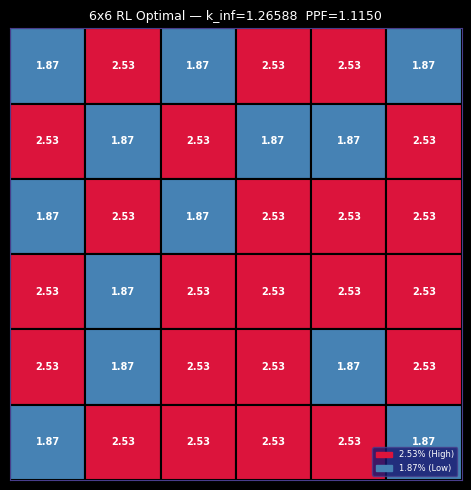

Grid saved -> ../Results/BWR_6x6_HP-RL/BWR_6x6_HP-RL_optimal_grid.png


In [5]:
rl_data = run_rl(cfg_rl, evaluate_fn, verbose=True)
print("done")

best         = summarise_rl_results(cfg_rl, rl_data, save=True, verbose=True)
enr_grid_opt = best["enr_grid"]

# Optimal grid plotting
fig_grid, ax = plt.subplots(1, 1, figsize=(5, 5))
fig_grid.patch.set_facecolor("black")
plot_enr_grid(
    enr_grid_opt,
    title = f"{BWR_N}x{BWR_N} RL Optimal — k_inf={best['keff']:.5f}  PPF={best['ppf']:.4f}",
    ax    = ax,
)
plt.tight_layout()
grid_path = f"{RESULTS_DIR}/{MODEL_NAME}_optimal_grid.png"
fig_grid.savefig(grid_path, dpi=150, bbox_inches="tight", facecolor="black")
plt.show()
print(f"Grid saved -> {grid_path}")


# Convergence plot + text report

Figure saved -> ../Results/BWR_6x6_HP-RL/BWR_6x6_HP-RL_rl_convergence.png


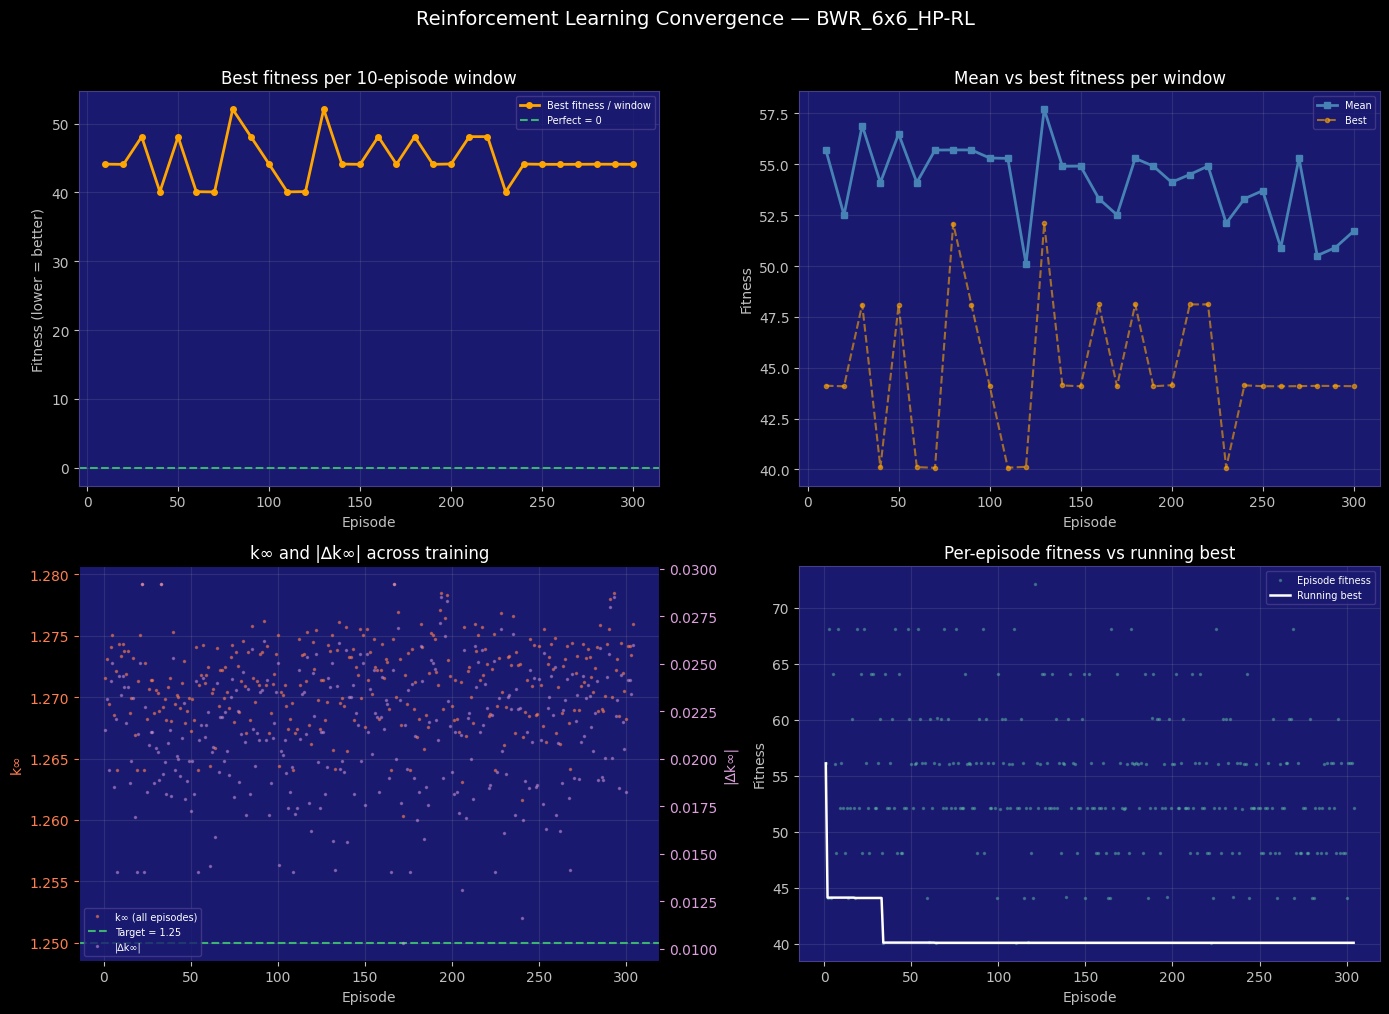

Report saved -> ../Results/BWR_6x6_HP-RL/BWR_6x6_HP-RL_report.txt


In [6]:
fig_conv = plot_rl_convergence(cfg_rl, rl_data, save=True)
plt.show()


report_path = f"{RESULTS_DIR}/{MODEL_NAME}_report.txt"
model_params = get_model_params(BWR_N)
with open(report_path, "w") as f:
    f.write(f"OpenMC-PRISM — Design Report (Reinforcement Learning)\n")
    f.write("=" * 70 + "\n\n")
    f.write(cfg_rl.summary() + "\n\n")
    f.write("-" * 70 + "\n")
    f.write("OpenMC model parameters\n")
    f.write("-" * 70 + "\n")
    for k, v in model_params.items():
        f.write(f"  {k:<28s}: {v}\n")
    f.write("\n" + "-" * 70 + "\n")
    f.write("Best design found\n")
    f.write("-" * 70 + "\n")
    f.write(f"  k∞              : {best['keff']:.5f}\n")
    f.write(f"  |∆k∞|           : {best['delta_k']:.5f}\n")
    f.write(f"  PPF                : {best['ppf']:.4f}\n")
    f.write(f"  Fitness            : {best['fitness']:.6f}\n")
    f.write(f"  Total OpenMC calls : {rl_data['n_evaluations']}\n")
    f.write(f"  Chromosome         : {list(best['chromosome'])}\n")

print(f"Report saved -> {report_path}")


# Comparison and Validation (Not necessary)

  VALIDATION: HIGH-FIDELITY OpenMC RUNS

[A] Reference layout — random valid enrichment layout with 23 high enrichment rods

[C] RL best layout — HiFi re-evaluation
All done
════════════════════════════════════════════════════════════════════════
  RL VALIDATION COMPARISON — Enrichment Layout Optimisation
════════════════════════════════════════════════════════════════════════
Design                                                k∞   σ(k∞) pcm      PPF
------------------------------------------------------------------------
  A — Reference layout          [HiFi]           1.27173       27.27   1.0952
  B — RL optimal layout         [LoFi]           1.26588       31.62   1.1150
  C — RL optimal layout (re-run)[HiFi]           1.27194       29.53   1.1089
════════════════════════════════════════════════════════════════════════

  Δk∞  (A->C): +0.00021  (+20.7 pcm)
  ΔPPF (A->C): +0.0137
  Δk∞  (B->C): +0.00606  |Z| = 14.00   check particles

Saved → ../Results/BWR_6x6_HP-RL/BWR_6x6_HP-R

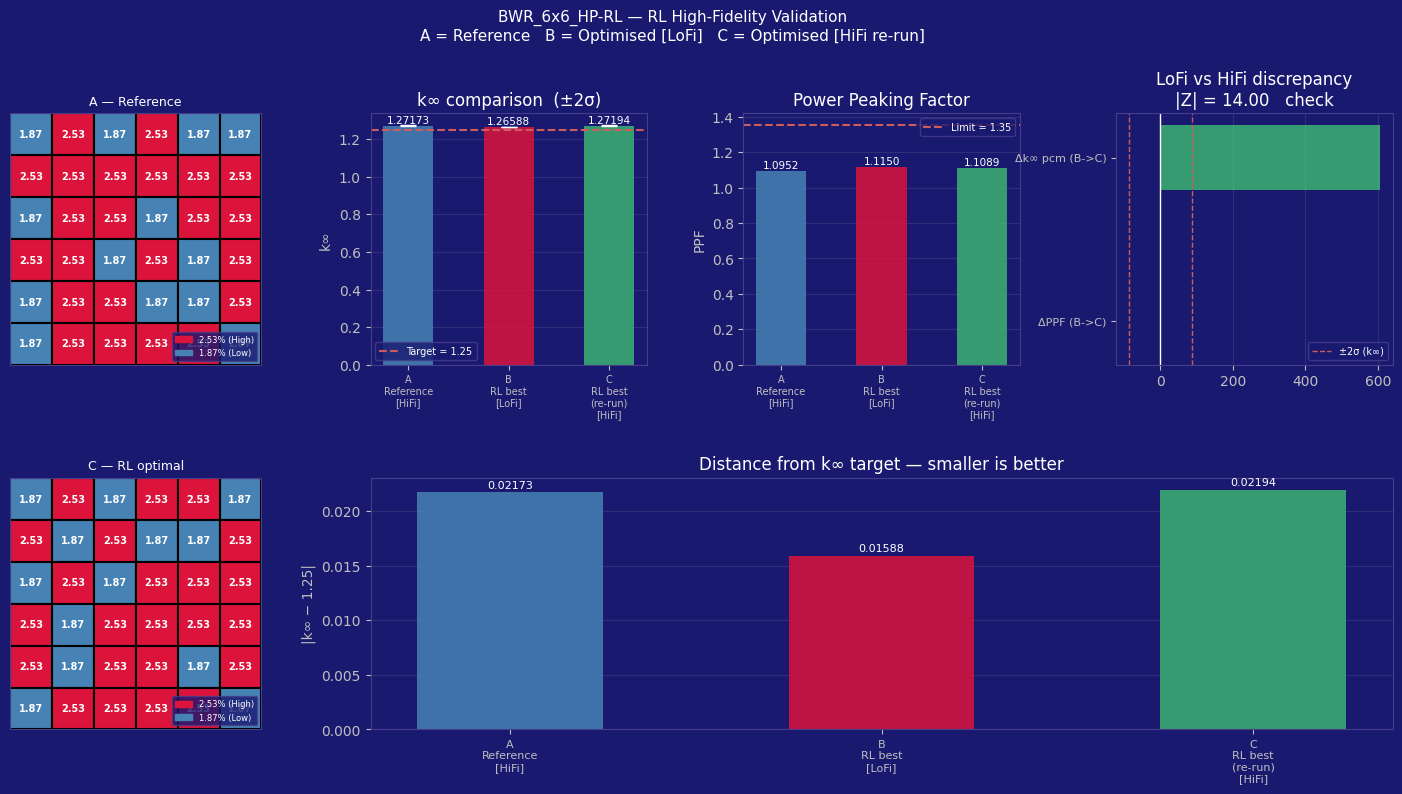

In [7]:
print("=" * 70)
print("  VALIDATION: HIGH-FIDELITY OpenMC RUNS")
print("=" * 70)


cfg_rl.n_particles = 50000  # Set to 50000+ for better research runs
cfg_rl.n_inactive  = 50
cfg_rl.n_active    = 200


rng = np.random.default_rng(cfg_rl.random_seed)


print(f"\n[A] Reference layout — random valid enrichment layout with {cfg_rl.n_high_rods} high enrichment rods")

x_ref_random = make_random_individual(cfg_rl, rng)
enr_grid_ref = cfg_rl.decode(x_ref_random)
hifi_ref     = evaluate_fn(x_ref_random)
hifi_ref.setdefault("keff_std", 0.0)


best_lofi = dict(keff=best["keff"], ppf=best["ppf"])

print("\n[C] RL best layout — HiFi re-evaluation")
# Re-run best discrete chromosome at HiFi particle count
hifi_opt = evaluate_fn(best["chromosome"])
hifi_opt.setdefault("keff_std", 0.0)


enr_grid_opt = best["enr_grid"]

print("All done")


fig_val = validate_and_plot_hifi(
    cfg          = cfg_rl,
    hifi_ref     = hifi_ref,
    best_lofi    = best_lofi,
    hifi_opt     = hifi_opt,
    enr_grid_ref = enr_grid_ref,
    enr_grid_opt = enr_grid_opt,
    filename     = f"{MODEL_NAME}_validation.png",
    algorithm    = "RL",
)
plt.show()


In [8]:
print("Keys inside 'best':", best.keys())


Keys inside 'best': dict_keys(['chromosome', 'keff', 'keff_std', 'ppf', 'fitness', 'enr_grid', 'delta_k'])
